# Run qGAN v3

Create experiment configs, run one existing config, and visualize the saved training results.


## Setup

Run this notebook from the repository root or from `qgan_v3/notebooks`.


In [2]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()

if (cwd / "qgan_v3" / "src").exists():
    repo_root = cwd
    qgan_root = cwd / "qgan_v3"
elif cwd.name == "notebooks" and (cwd.parent / "src").exists():
    qgan_root = cwd.parent
    repo_root = qgan_root.parent
else:
    raise RuntimeError("Run this notebook from the repository root or qgan_v3/notebooks.")

os.chdir(repo_root)
src_path = qgan_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Repository root:", repo_root)
print("qGAN root:", qgan_root)


Repository root: /home/benat/Qiskit-IBM
qGAN root: /home/benat/Qiskit-IBM/qgan_v3


## Create Configs

This creates the test config files under `qgan_v3/data/test`.


In [ ]:
from config_manager.config_manager import create_configs

test_config_file = qgan_root / "src" / "config_manager" / "test_config.yaml"
create_configs(test_config_file, overwrite=True)


## Select Config

Change these values to choose another generated config.


In [3]:
from config_manager.config_manager import load_config_file

implementation = "base"  # base, ang, amp
n_qubits = 3
execution_type = "noiseless"  # noiseless, noisy
gradient_method = "PSR"  # PSR, SPSA, REG
device = "CPU"  # CPU, GPU
seed = 0

config_path = qgan_root / "data" / "test" / f"{implementation}-q{n_qubits}-{execution_type}-{gradient_method}-{device}-seed{seed}" / "config.yaml"
config = load_config_file(config_path)
config_path


PosixPath('/home/benat/Qiskit-IBM/qgan_v3/data/test/base-q3-noiseless-PSR-CPU-seed0/config.yaml')

In [4]:
config


{'run': {'id': 'base-q3-noiseless-PSR-CPU-seed0',
  'data_path': 'qgan_v3/data/test',
  'seed': 0,
  'device': 'CPU'},
 'experiment': {'implementation': 'base',
  'execution_type': 'noiseless',
  'n_qubits': 3,
  'gradient_method': 'PSR'},
 'training': {'max_iterations': 2,
  'gen_iterations': 1,
  'disc_iterations': 1,
  'print_every': 1},
 'dataset': {'id': 'specific_distribution',
  'reset': False,
  'type': 'quantum',
  'source': 'specific_distribution',
  'parameters': {}},
 'circuits': {'reset': False,
  'generator': 'real_amplitudes',
  'discriminator': 'efficient_su2'},
 'backend': {'reset': True,
  'precision': 0.5,
  'simulator': {'data_type': 'double',
   'noiseless_method': 'statevector',
   'noisy_method': 'density_matrix',
   'gpu': {'cuStateVec_enable': True,
    'batched_shots_gpu': True,
    'blocking_enable': False,
    'runtime_parameter_bind_enable': True}},
  'real': {'id': 'ibm_basquecountry',
   'name': 'ibm_basquecountry',
   'channel': 'ibm_quantum_platform',
 

## Run

This runs training from the selected existing config file.


In [5]:
from main import run_train

model_g, model_d, eval_g = run_train(config_path)


Epoch | Generator cost | Discriminator cost | Eval | Best eval | Time |
Training complete: 
   Data path: qgan_v3/data/test/base-q3-noiseless-PSR-CPU-seed0 
   Best eval: 0.19128608402461225 
   Total time: 1.5300657749176025


## Visualize

This loads the selected run folder and displays circuits, input data, probability distributions, and training results depending on the selected implementation.


Circuits file created.
Run path: qgan_v3/data/test/base-q3-noiseless-PSR-CPU-seed0
Circuits: 4 (generator, discriminator, randomizer, real circuits)


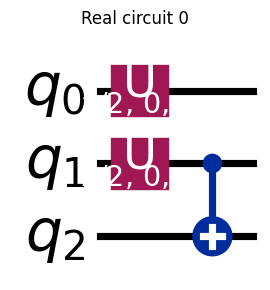

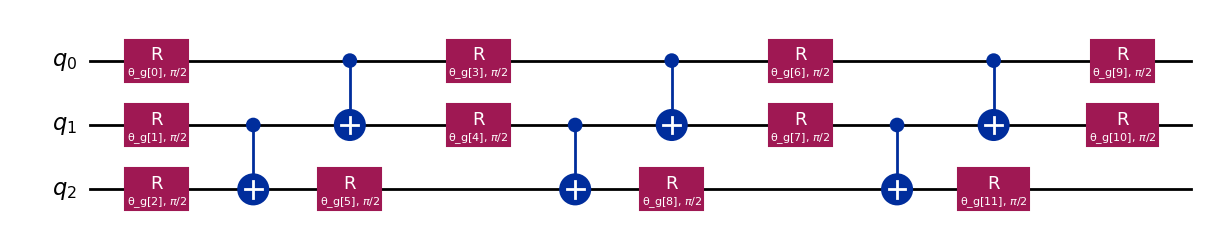

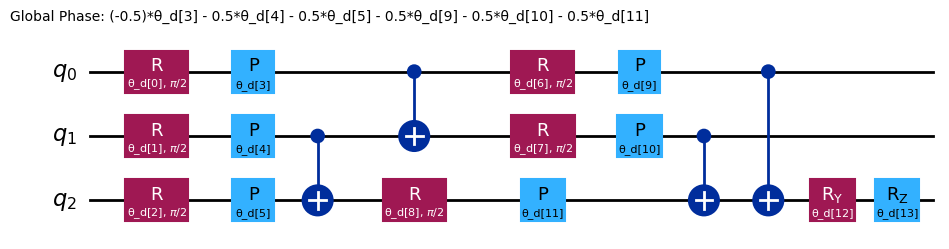

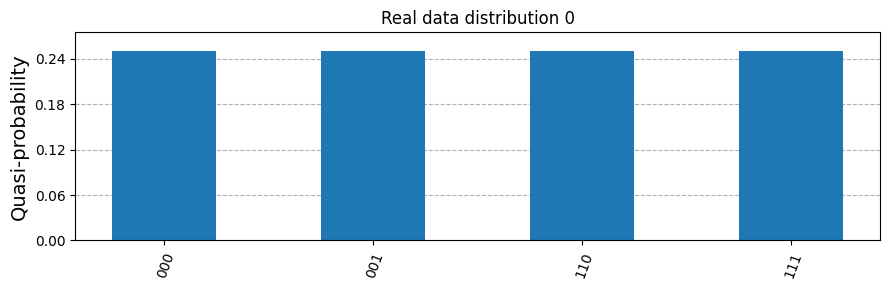

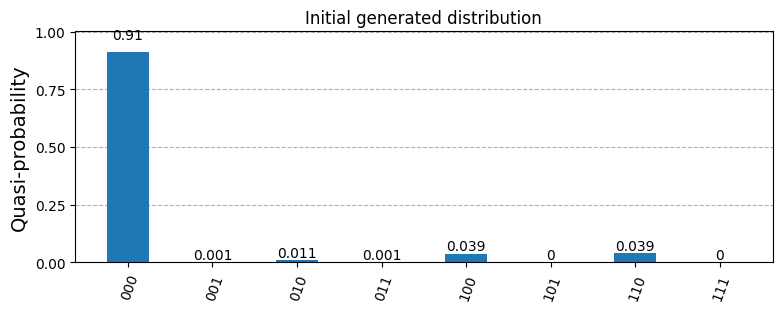

[ 0.0497503   0.2582976  -0.27740267 -0.2559261  -0.31089042  0.20136323
  0.18439635  0.24240805  0.3107313   0.17927499 -0.03301884  0.18581235
 -0.24172334  0.09792169]


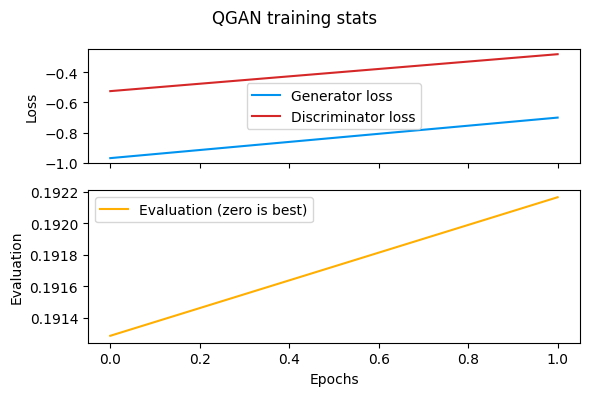

Training complete: qgan_v3/data/test/base-q3-noiseless-PSR-CPU-seed0/training_data.pth 
Best evaluation: 0.19128608402461225 in epoch 0 
Improvement: 0.0


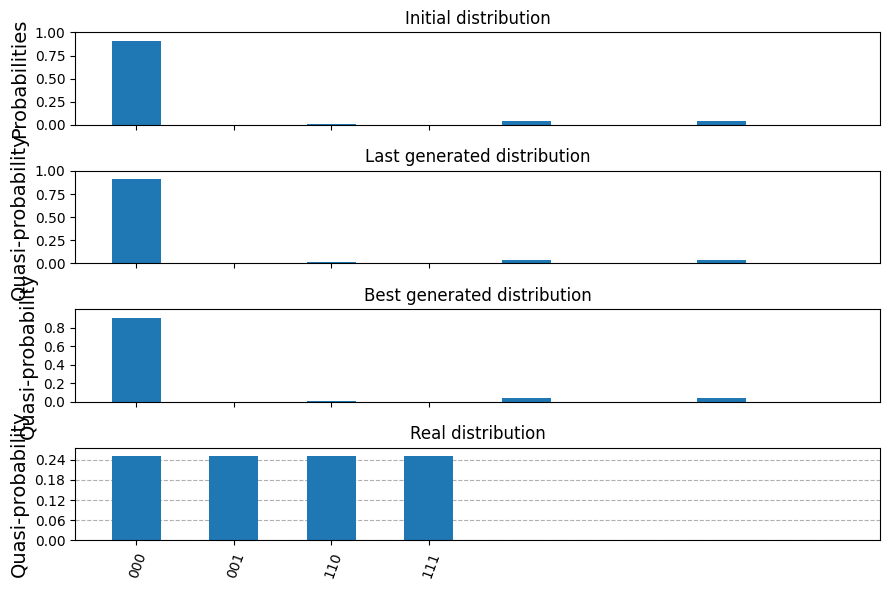

In [6]:
from visualization_utils import run_visualization

visual_config = {
    "train": False,
    "draw_circuits": True,
    "draw_images": config["dataset"]["type"] == "classical",
    "draw_probs": True,
    "draw_results": True,
}

run = run_visualization(config_path, visual_config)


## Saved Data


In [7]:
training_data_file = config_path.parent / "training_data.pth"
training_data_file


PosixPath('/home/benat/Qiskit-IBM/qgan_v3/data/test/base-q3-noiseless-PSR-CPU-seed0/training_data.pth')